In [1]:
import json
import os
import sys
import hashlib
from pathlib import Path
from datetime import datetime

import wandb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from dotenv import load_dotenv

sys.path.append(os.path.abspath("../.."))

from src.utils.get_trainer import get_trainer
from src.utils.loggers import WandbLogger
from src.utils.telegram import send_message

# Create OOF and Test pred

In [2]:
# ===== User config =====
load_dotenv(dotenv_path="../../.env")

model_name = "mlp"
data_id = "033"

n_trial = 2

n_fold = 5
seed = 42

In [3]:
# === get params, n_fold, seed, and batch_rows ===
study_name = f"{model_name}-{data_id}"
feature_dir = Path(f"../../artifacts/features/{data_id}")

params_id = f"trl{n_trial}"
params_path = f"../../artifacts/optuna/{study_name}/{params_id}.json"

with open(feature_dir / "meta.json", "r") as f:
    meta = json.load(f)

train_paths = meta["train_paths"]
test_paths = meta["test_paths"]
level = meta["level"]

with open(params_path, "r") as f:
    manifest = json.load(f)

params = manifest["params"]
opts = manifest["opts"]

print("Manifest path: ", params_path)
print("Params:\n", params)
print("opts: ", opts)

Manifest path:  ../../artifacts/params/mlp-033/trl2.json
Params:
 {'hidden_dim1': 864, 'hidden_dim2': 256, 'hidden_dim3': -1, 'hidden_dim4': -1, 'batch_size': 832, 'lr': 0.015304852121831466, 'lr_min': 0.00011128853174905746, 'dropout_rate': 0.4, 'activation': 'SiLU', 'opts': {'earlys_stopping_rounds': 5, 'max_epochs': 10, 'min_epochs': 4}}
opts:  {'opts': {'earlys_stopping_rounds': 5, 'max_epochs': 10, 'min_epochs': 4}}


In [4]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))

run = wandb.init(
    project=wandb_project,
    group=study_name,
    name=params_id,
    job_type="cv_training",
    tags=[model_name, level],
    config={
        "data_id": data_id,
        "n_fold": n_fold,
        "seed": seed,
        **params,
        **opts
    },
    dir="../../artifacts"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/hanse/.netrc
wandb: Currently logged in as: kaitookano (kaitookano-waseda-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# === Training ===
trainer_class = get_trainer(model_name)
trainer = trainer_class(
    data_id,
    train_paths,
    test_paths,
    features=None,
    target="target",
    fold_col=None,
    weight_col=None,
    cat_cols=None,
    params=params,
    n_fold=n_fold,
    seed=seed,
    gpu=True,
    opts=opts
)

result = trainer.fit(
    loggers=[WandbLogger(run=run)]
)

Fold Col: 5fold-s42
===== Fold 1 / 5 =====
Free CPU Mem: 16.89 GB
Free GPU Mem: 6.64 GB
Epoch 1: Train Logloss = 0.13811, Val Logloss = 0.13651
New best model saved at epoch 1, Logloss: 0.13651
Epoch 2: Train Logloss = 0.13619, Val Logloss = 0.13494
New best model saved at epoch 2, Logloss: 0.13494
Epoch 3: Train Logloss = 0.13462, Val Logloss = 0.13357
New best model saved at epoch 3, Logloss: 0.13357
Epoch 4: Train Logloss = 0.13358, Val Logloss = 0.13287
New best model saved at epoch 4, Logloss: 0.13287
Epoch 5: Train Logloss = 0.13278, Val Logloss = 0.13232
New best model saved at epoch 5, Logloss: 0.13232
Epoch 6: Train Logloss = 0.13215, Val Logloss = 0.13188
New best model saved at epoch 6, Logloss: 0.13188
Epoch 7: Train Logloss = 0.13146, Val Logloss = 0.13139
New best model saved at epoch 7, Logloss: 0.13139
Epoch 8: Train Logloss = 0.13095, Val Logloss = 0.13116
New best model saved at epoch 8, Logloss: 0.13116
Epoch 9: Train Logloss = 0.13045, Val Logloss = 0.13091
New best

epoch_f1,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
epoch_f2,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch_f3,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
epoch_f4,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
epoch_f5,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
meta/f1/lr,██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▂▂▂▁▁
meta/f2/lr,███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▁▁
meta/f3/lr,███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▂▂▂▁▁
meta/f4/lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁▁
meta/f5/lr,███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▂▂▂▁▁
train/f1/auc,▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇██


In [6]:
# ===== Save Manifest, OOF, and Test pred=====
runs_root = Path("../../runs")
run_id = f"{model_name}-{data_id}-{params_id}-{n_fold}fold-s{seed}"
run_dir = runs_root / run_id
run_dir.mkdir(parents=True, exist_ok=True)

s = json.dumps(params, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
phash = hashlib.sha256(s.encode()).hexdigest()[:10]

manifest = {
    "run_id": run_id,
    "wandb_id": run.id,
    "wandb_url": run.url,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": model_name,
    "data_id": data_id,
    "n_fold": n_fold,
    "seed": seed,
    "feature_dir": str(feature_dir.resolve()),
    "phash": phash,
    "param_source": params_path,
    "params": params,
    "run_dir": str(run_dir.resolve()),
    "cv_score": result.oof_score,
    "submission": {
        "competition": None,
        "ref": None,
        "file": None,
        "public_score": None,
        "private_score": None,
        "submitted_at": None
    }
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)

print("manifest saved", run_dir / "manifest.json")

# oof and test pred
np.save(run_dir / "oof.npy", result.oof)
np.save(run_dir / "test.npy", result.test_pred)

print(f"oof and test preds saved successfully in:\n{run_dir}")
send_message(
    f"✅ Finished CV for {run_id}!"
    f"\nScore: {round(result.oof_score, 5)}"
)

manifest saved ../../runs/mlp-033-trl2-5fold-s42/manifest.json
oof and test preds saved successfully in:
../../runs/mlp-033-trl2-5fold-s42
✅ Message sent.


# Check Feature Importance (Only XGB)

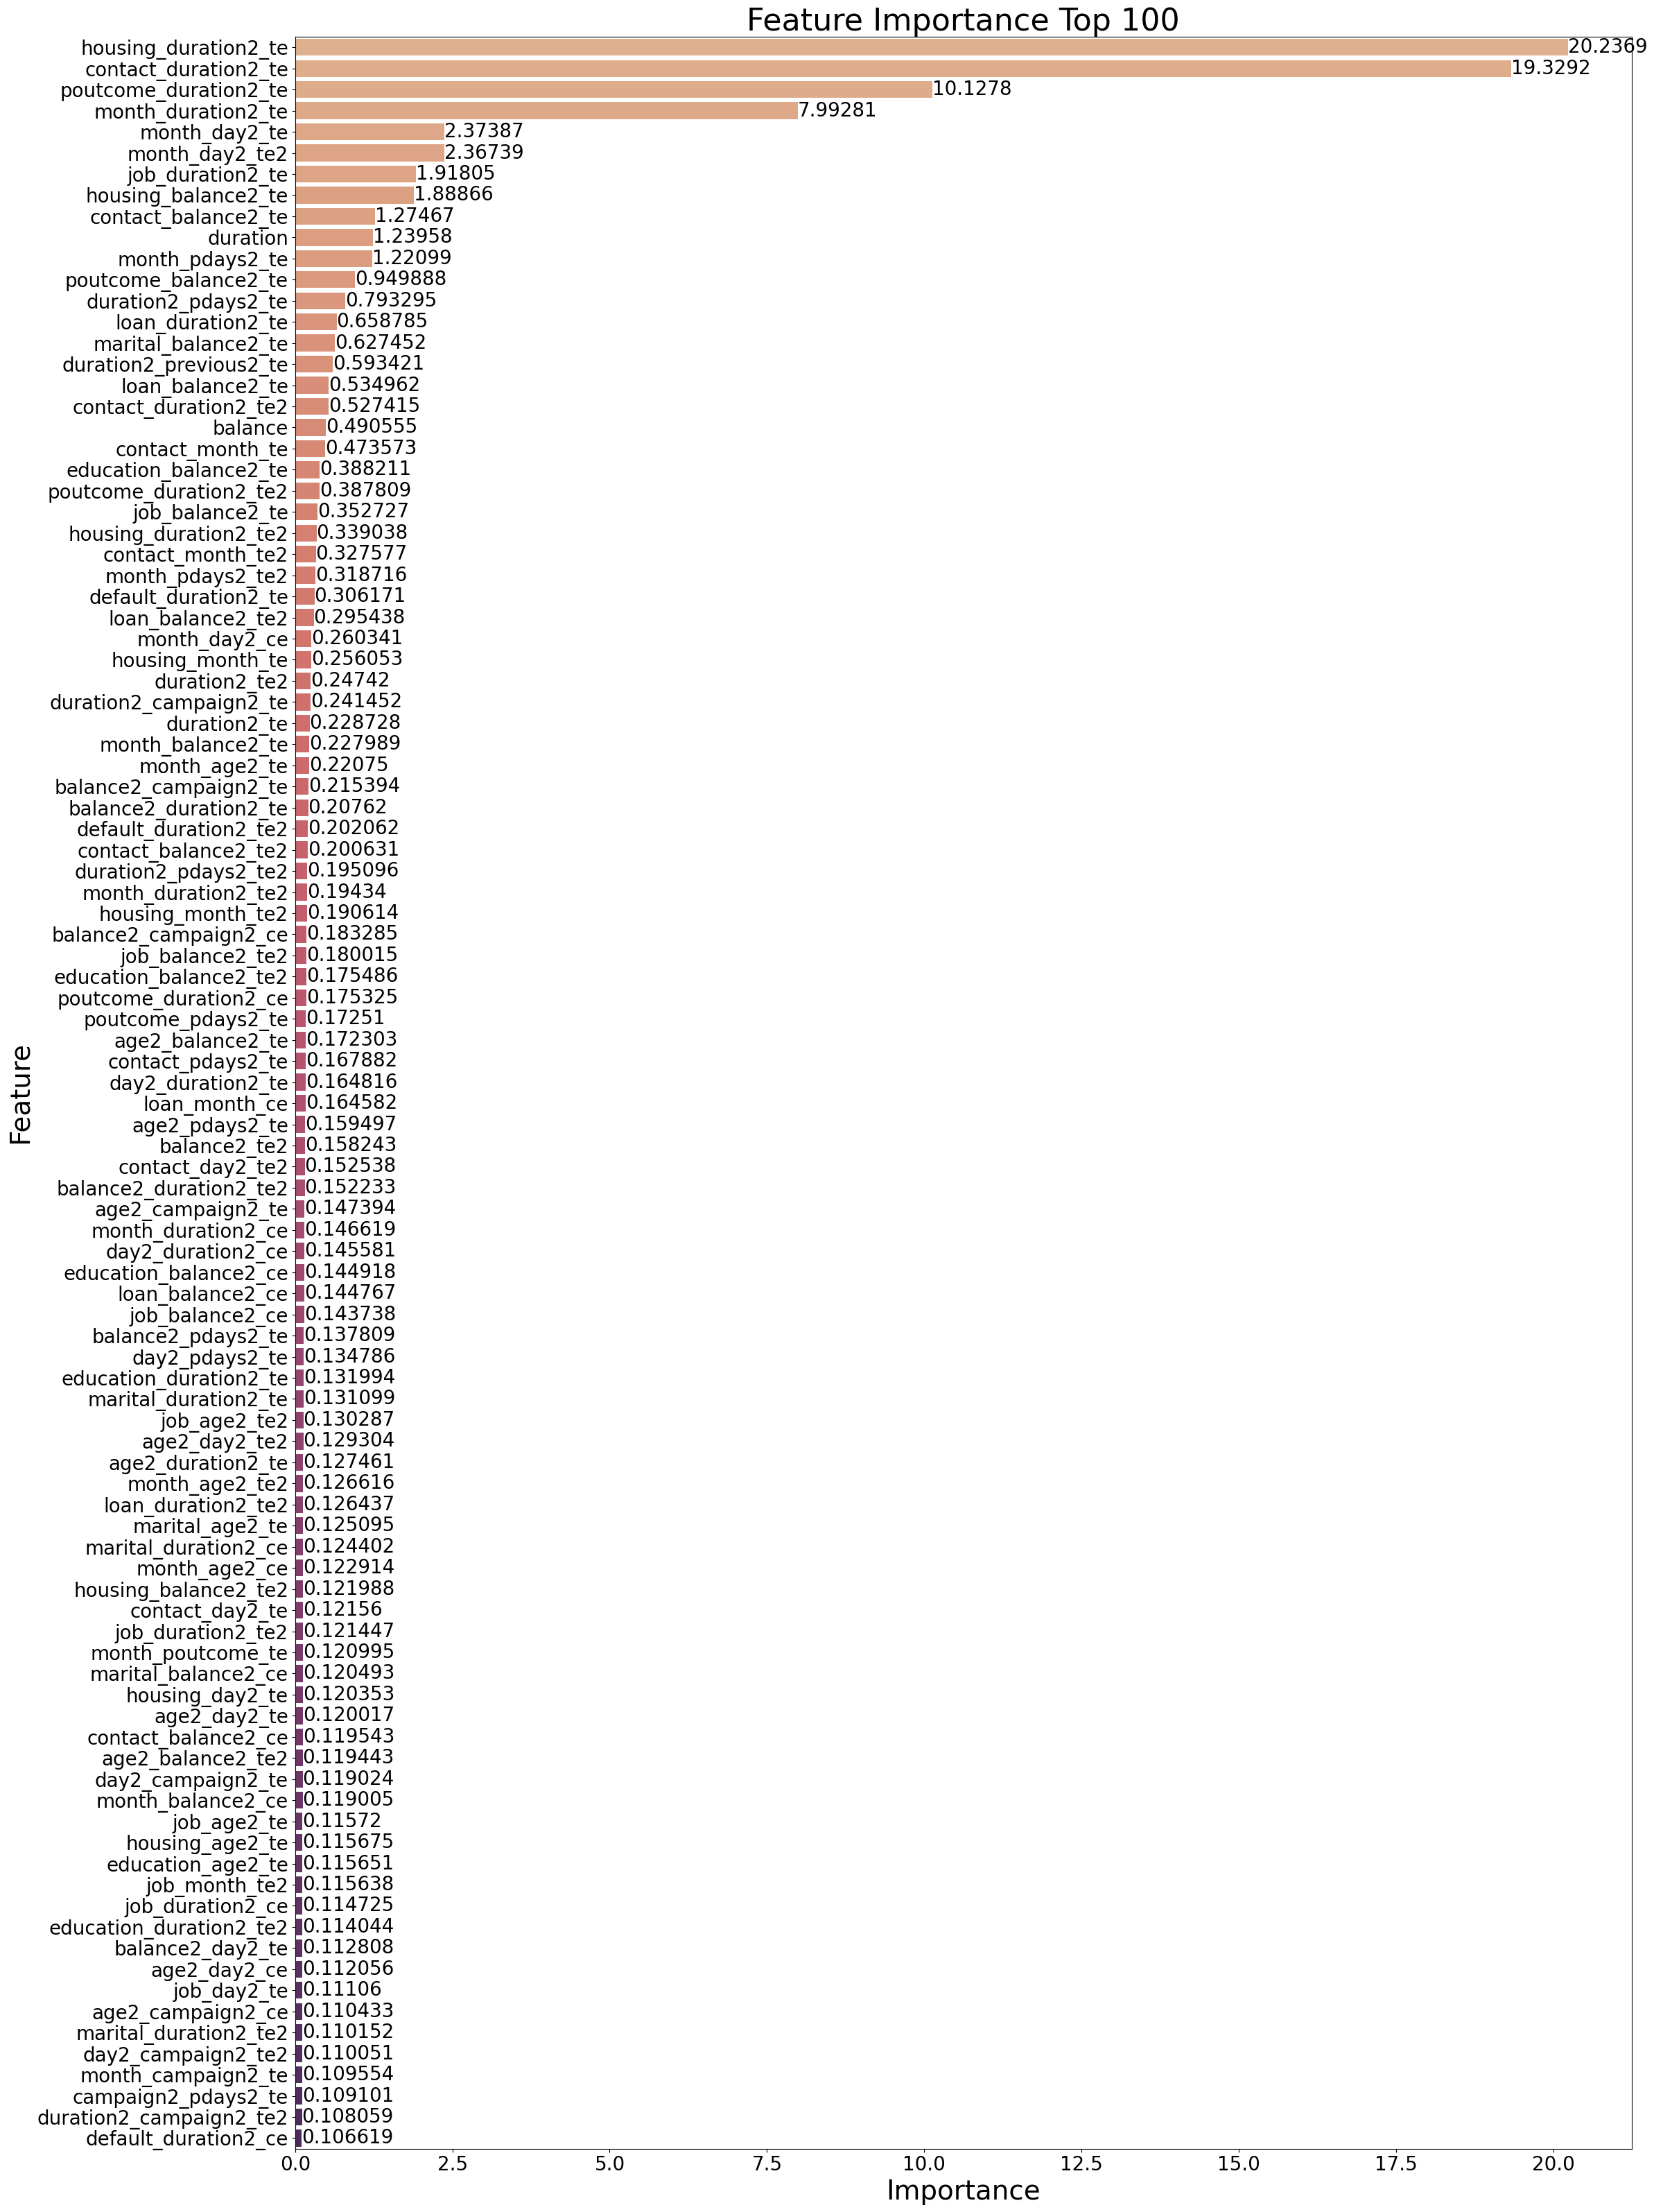

FI graph saved successfully to ../../runs/xgb-033-trl17-5fold-s42


In [10]:
# Plot feature importance and get top columns
df = result.fi_mean.to_pandas()
df_top100 = df[:100]

fig, ax = plt.subplots(figsize=(24, 32))
sns.barplot(
    data=df_top100,
    y="Feature",
    x="mean_ratio",
    orient="h",
    palette="flare",
    hue="Feature",
    ax=ax
)
for container in ax.containers:
    labels = ax.bar_label(container)
    for label in labels:
        label.set_fontsize(20)
plt.title("Feature Importance Top 100", fontsize=32)
plt.xlabel("Importance", fontsize=28)
plt.ylabel("Feature", fontsize=28)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
plt.tight_layout()

fig.savefig(run_dir / "feature_importance.png", dpi=200, bbox_inches="tight")
fig.savefig(run_dir / "feature_importance.svg", bbox_inches="tight")

plt.show()

print(f"FI graph saved successfully to {run_dir}")

In [11]:
thresholds = [0.90, 0.95, 0.99]       # しきい値リスト

total = df["mean_ratio"].sum()
print("All cols ", len(df))

out = {}
for th in thresholds:
    limit = th * total                # このしきい値に対応する累積比率

    # 累積と K を計算（「閾値を超える要素も1つ含める」ロジック）
    cum = df["mean_ratio"].cumsum()
    k = int((cum <= limit).sum())
    if k < len(df):
        k += 1

    drop_cols = df["Feature"].iloc[k:].tolist()
    print(f"\nThreshold {th:.2f} → Drop {len(drop_cols)} cols")
    out[str(k)] = drop_cols

path = run_dir / "drop_cols.json"
with open(path, "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=4)
print(f"saved: {path}")

All cols  302

Threshold 0.90 → Drop 193 cols

Threshold 0.95 → Drop 132 cols

Threshold 0.99 → Drop 44 cols
saved: ../../runs/xgb-033-trl17-5fold-s42/drop_cols.json
